In [1]:
from moabb.datasets import BNCI2014_001
import moabb.paradigms as mp
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.evaluations import WithinSessionEvaluation
import random
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from functools import partial


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = BNCI2014_001()
num=10


In [3]:

all_scaled = []
used_combinations = set()

base_channels = [
    'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3',
    'CP4', 'CPz', 'Cz', 'FC2', 'FC3', 'FC4', 'FCz',
    'P1', 'P2', 'POz', 'Pz', 'C1', 'FC1', 'Fz'
]

while len(all_scaled) < num:
    num_inc=random.randint(1, 4)
    scaled = sorted(random.sample(base_channels, num_inc))
    key = tuple(scaled)

    if key in used_combinations:
        continue

    used_combinations.add(key)
    all_scaled.append(scaled)

print(all_scaled)

[['CP4', 'FC3', 'P2'], ['Fz'], ['C6', 'P1', 'Pz'], ['CPz', 'FC4', 'FCz'], ['CPz', 'FC2', 'FC3', 'P2'], ['CP3'], ['C1', 'FC3'], ['C1', 'FC1', 'P1'], ['CP2', 'FC1', 'FC3'], ['C5', 'CP1', 'CP2', 'P2']]


In [4]:
def scale_EEG(X, channels_to_scale, channels, scale_factor=2):
    X = X.copy()
        
    idx = [
        channels.index(ch)
        for ch in channels_to_scale
    ]

    X[:, idx, :] *= scale_factor
    
    return X

In [5]:
all_results = []
all_avgs = []
factor=random.uniform(1.5, 2)

for scaled in all_scaled:
        
    scaler = FunctionTransformer(
        partial(
            scale_EEG,
            channels_to_scale=scaled,
            channels=base_channels,
            scale_factor=factor
        )
    )

    pipeline = make_pipeline(
        scaler,
        CSP(n_components=8),
        LDA()
    )

    

    paradigm = mp.MotorImagery(
        scorer=["accuracy", "balanced_accuracy", "f1_macro"],
    )

    evaluation = WithinSessionEvaluation(
        paradigm=paradigm,
        datasets=[dataset],
        overwrite=True,
        hdf5_path=None
    )

    results = evaluation.process({"csp+lda": pipeline})
    all_results.append(results)

    
    avgRes=[]
    avgRes=pd.DataFrame(avgRes)
    avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()
    avgRes['Balanced Accuracy']=results.groupby('session')['score_balanced_accuracy'].mean()
    avgRes['score_f1_macro']=results.groupby('session')['score_f1_macro'].mean()


    all_avgs.append(avgRes)

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 50 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 22 dim * 1e+16  ma

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 64 (2.2e-16 eps * 22 dim * 1.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 64 (2.2e-16 eps * 22 dim * 1.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 64 (2.2e-16 eps * 22 dim * 1.3e+

Choosing from all possible events


...

Computing rank from data with rank=None
    Using tolerance 89 (2.2e-16 eps * 22 dim * 1.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 89 (2.2e-16 eps * 22 dim * 1.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 89 (2.2e-16 eps * 22 dim * 1.8e+

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 59 (2.2e-16 eps * 22 dim * 1.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 59 (2.2e-16 eps * 22 dim * 1.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 59 (2.2e-16 eps * 22 dim * 1.2e+

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 79 (2.2e-16 eps * 22 dim * 1.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 79 (2.2e-16 eps * 22 dim * 1.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 79 (2.2e-16 eps * 22 dim * 1.6e+

Train
Avg accuracy=  0.6508282
Avg balanced accuracy=  0.65103704
Avg macro F1=  0.6480979

Test
Avg accuracy=  0.7061659
Avg balanced accuracy=  0.70631754
Avg macro F1=  0.7039217


   subject session  score_accuracy
0        1  0train        0.732886
1        1   1test        0.750944
2        2  0train        0.632692
3        2   1test        0.603122
4        3  0train        0.843745
5        3   1test        0.862874
6        4  0train        0.525402
7        4   1test        0.660599
8        5  0train        0.371500
9        5   1test        0.457967
10       6  0train        0.493430
11       6   1test        0.485832
12       7  0train        0.792438
13       7   1test        0.865287
14       8  0train        0.809316
15       8   1test        0.816425
16       9  0train        0.656044
17       9   1test        0.852444


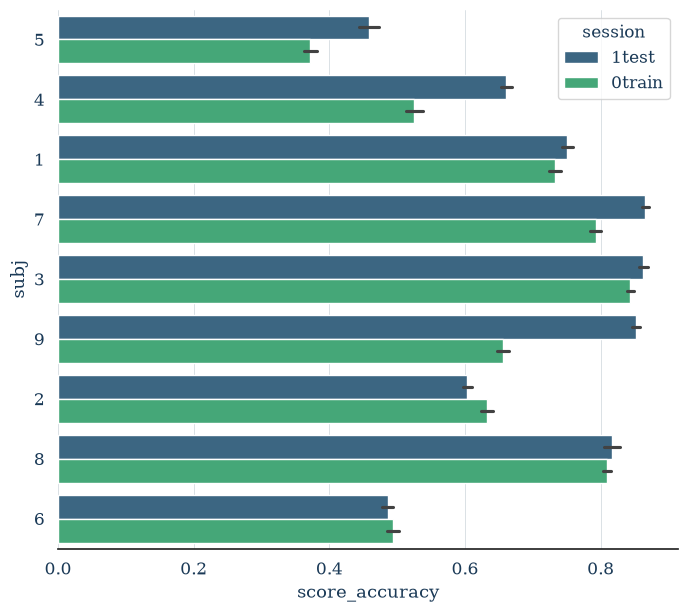

In [6]:
TrainAccuracy=0
TestAccuracy=0
BTrainAccuracy=0
BTestAccuracy=0
FTrain=0
FTest=0

for dset in all_avgs:
    TrainAccuracy+=dset.iloc[0]['Accuracy']
    TestAccuracy+=dset.iloc[1]['Accuracy']
    BTrainAccuracy+=dset.iloc[0]['Balanced Accuracy']
    BTestAccuracy+=dset.iloc[1]['Balanced Accuracy']
    FTrain+=dset.iloc[0]['score_f1_macro']
    FTest+=dset.iloc[1]['score_f1_macro']

print("Train")
print("Avg accuracy= ", TrainAccuracy/num)
print("Avg balanced accuracy= ", BTrainAccuracy/num)
print("Avg macro F1= ", FTrain/num)

print("\nTest")
print("Avg accuracy= ", TestAccuracy/num)
print("Avg balanced accuracy= ", BTestAccuracy/num)
print("Avg macro F1= ", FTest/num)
print("\n")

import pandas as pd

results = pd.concat(all_results, ignore_index=True)

avg_results = (
    results
    .groupby(["subject", "session"], as_index=False)["score_accuracy"]
    .mean()
)

print(avg_results)

fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()



In [5]:
factors=[3, 4, 5]
num=2


In [6]:

all_scaled = []
used_combinations = set()

base_channels = [
    'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3',
    'CP4', 'CPz', 'Cz', 'FC2', 'FC3', 'FC4', 'FCz',
    'P1', 'P2', 'POz', 'Pz', 'C1', 'FC1', 'Fz'
]

while len(all_scaled) < num:
    num_inc=random.randint(3,3)
    scaled = sorted(random.sample(base_channels, num_inc))
    key = tuple(scaled)

    if key in used_combinations:
        continue

    used_combinations.add(key)
    all_scaled.append(scaled)

print(all_scaled)

[['C6', 'CP1', 'CP3'], ['FC4', 'Fz', 'P1']]


In [7]:
accuracy=[]
for factor in factors:
    all_avgs = []

    for scaled in all_scaled:
            
        scaler = FunctionTransformer(
            partial(
                scale_EEG,
                channels_to_scale=scaled,
                channels=base_channels,
                scale_factor=factor
            )
        )

        pipeline = make_pipeline(
            scaler,
            CSP(n_components=8),
            LDA()
        )

        

        paradigm = mp.MotorImagery(
            scorer=["accuracy", "balanced_accuracy", "f1_macro"],
        )

        evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

        results = evaluation.process({"csp+lda": pipeline})
        
        avgRes=[]
        avgRes=pd.DataFrame(avgRes)
        avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

        all_avgs.append(avgRes)
    
    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    accuracy.append(TestAccuracy/num)

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 71 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 71 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 71 (2.2e-16 eps * 22 dim * 1.4e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 1.2e+02 (2.2e-16 eps * 22 dim * 2.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.2e+02 (2.2e-16 eps * 22 dim * 2.5e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.2e+02 (2.2e-16 eps *

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


...

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 1.4e+02 (2.2e-16 eps * 22 dim * 2.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.4e+02 (2.2e-16 eps * 22 dim * 2.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.4e+02 (2.2e-16 eps *

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 22 dim * 2.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 22 dim * 2.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 22 di

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


In [12]:
accuracy

[np.float32(0.7081636), np.float32(0.70430195), np.float32(0.7053169)]

(0.7, 0.8)

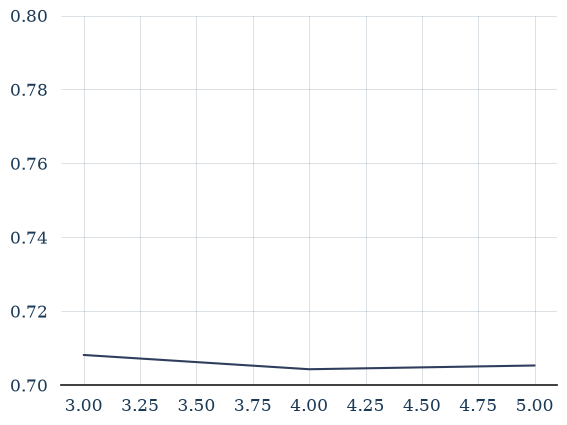

In [14]:
plt.plot(factors, accuracy)
plt.ylim(0.7, 0.8)

In [9]:
sum(accuracy)/len(accuracy)

np.float32(0.70592755)

In [18]:
X, labels, meta = paradigm.get_data(dataset=dataset, subjects=[1])

In [21]:
before=X[1, 1, :]

In [31]:
def scale_EEG2(X, scale_factor=5):
    X = X.copy()

    X*= scale_factor
    
    return X

In [32]:
after=scale_EEG2(before)

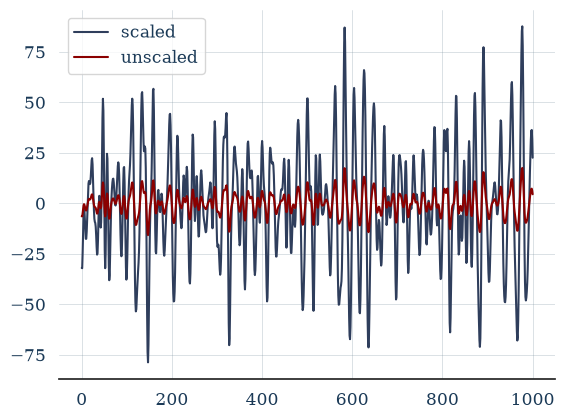

In [46]:
plt.plot(after, label="scaled")
plt.plot(before, color='#8B0000', label="unscaled")
plt.legend()
plt.show()

In [47]:
accuracy

[np.float32(0.7081636), np.float32(0.70430195), np.float32(0.7053169)]

Train
Avg accuracy=  0.65833837
Avg balanced accuracy=  0.0
Avg macro F1=  0.0

Test
Avg accuracy=  0.7053169
Avg balanced accuracy=  0.0
Avg macro F1=  0.0


   subject session  score_accuracy
0        1  0train        0.739504
1        1   1test        0.753297
2        2  0train        0.656080
3        2   1test        0.597036
4        3  0train        0.861222
5        3   1test        0.864489
6        4  0train        0.537750
7        4   1test        0.673805
8        5  0train        0.367937
9        5   1test        0.423654
10       6  0train        0.489716
11       6   1test        0.485783
12       7  0train        0.798790
13       7   1test        0.861162
14       8  0train        0.808953
15       8   1test        0.795039
16       9  0train        0.676830
17       9   1test        0.847187


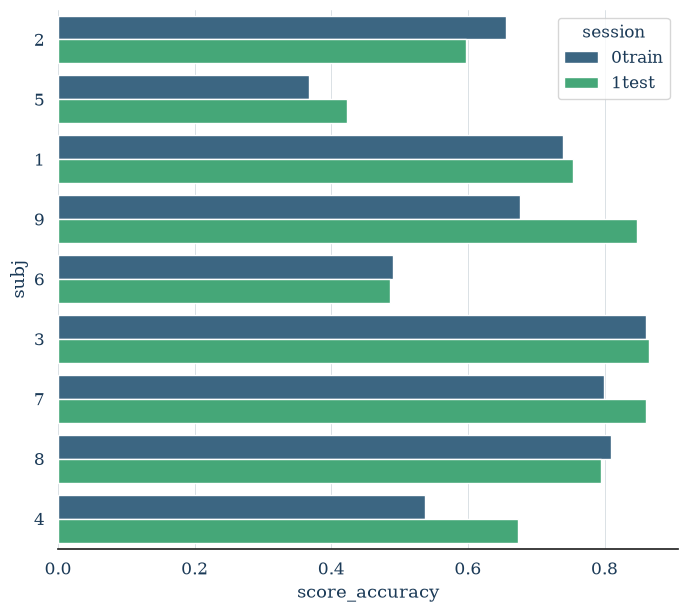

In [51]:
TrainAccuracy=0
TestAccuracy=0
BTrainAccuracy=0
BTestAccuracy=0
FTrain=0
FTest=0

for dset in all_avgs:
    TrainAccuracy+=dset.iloc[0]['Accuracy']
    TestAccuracy+=dset.iloc[1]['Accuracy']

print("Train")
print("Avg accuracy= ", TrainAccuracy/num)
print("Avg balanced accuracy= ", BTrainAccuracy/num)
print("Avg macro F1= ", FTrain/num)

print("\nTest")
print("Avg accuracy= ", TestAccuracy/num)
print("Avg balanced accuracy= ", BTestAccuracy/num)
print("Avg macro F1= ", FTest/num)
print("\n")

import pandas as pd


avg_results = (
    results
    .groupby(["subject", "session"], as_index=False)["score_accuracy"]
    .mean()
)

print(avg_results)

fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()

